# 01 — Exploratory Data Analysis
Explore both datasets before preprocessing and training.

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Cell 2 — Load both datasets
spotify = pd.read_csv("../data/SpotifySongs.csv")
genres  = pd.read_csv("../data/GenreFeatures.csv")

In [3]:
# Cell 3a — SpotifySongs: shape, dtypes, first 5 rows
print("=== SpotifySongs ===")
print("Shape:", spotify.shape)
print("\nData types:")
print(spotify.dtypes)
print("\nFirst 5 rows:")
spotify.head()

=== SpotifySongs ===
Shape: (114000, 21)

Data types:
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

First 5 rows:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Cell 3b — GenreFeatures: shape, dtypes, first 5 rows
print("=== GenreFeatures ===")
print("Shape:", genres.shape)
print("\nData types:")
print(genres.dtypes)
print("\nFirst 5 rows:")
genres.head()

=== GenreFeatures ===
Shape: (1000, 60)

Data types:
filename                       str
length                       int64
chroma_stft_mean           float64
chroma_stft_var            float64
rms_mean                   float64
rms_var                    float64
spectral_centroid_mean     float64
spectral_centroid_var      float64
spectral_bandwidth_mean    float64
spectral_bandwidth_var     float64
rolloff_mean               float64
rolloff_var                float64
zero_crossing_rate_mean    float64
zero_crossing_rate_var     float64
harmony_mean               float64
harmony_var                float64
perceptr_mean              float64
perceptr_var               float64
tempo                      float64
mfcc1_mean                 float64
mfcc1_var                  float64
mfcc2_mean                 float64
mfcc2_var                  float64
mfcc3_mean                 float64
mfcc3_var                  float64
mfcc4_mean                 float64
mfcc4_var                  float64
mf

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [5]:
# Cell 4 — Null value check for both datasets
print("SpotifySongs — null counts:")
print(spotify.isnull().sum())
print("\nGenreFeatures — null counts:")
print(genres.isnull().sum())

SpotifySongs — null counts:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

GenreFeatures — null counts:
filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
per

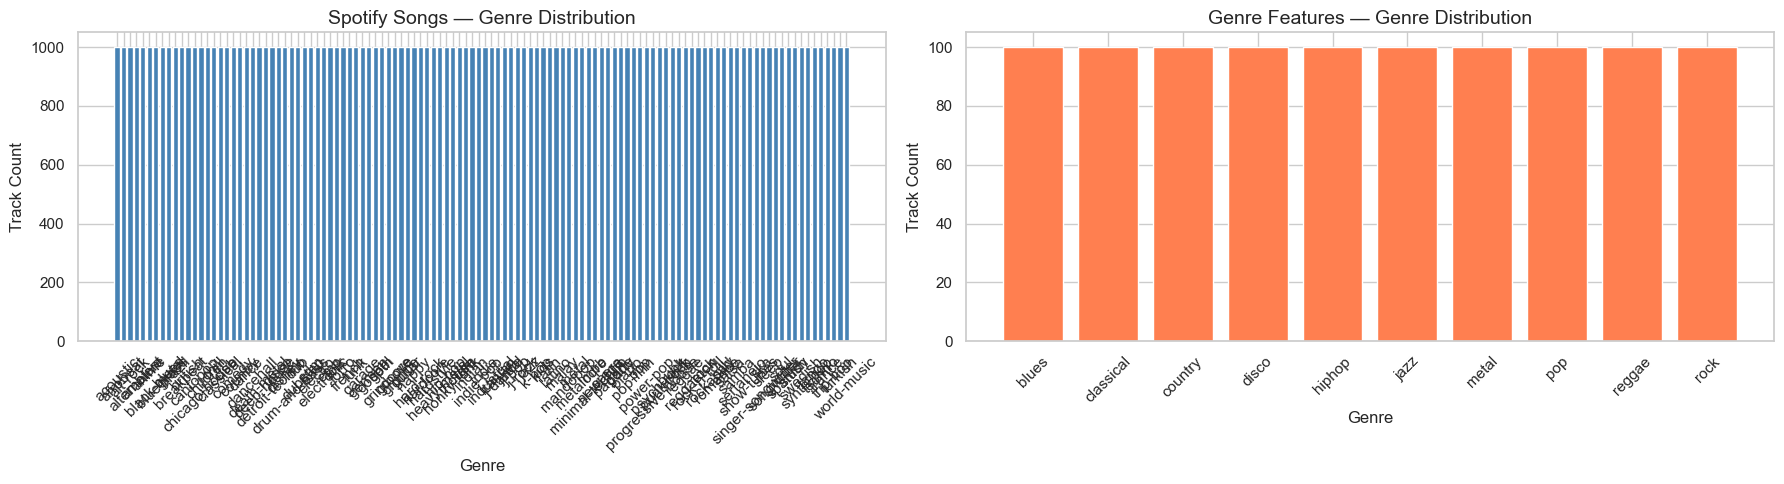

In [6]:
# Cell 5 — Genre distribution bar charts (side by side)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# SpotifySongs genre distribution
spotify_counts = spotify['track_genre'].value_counts()
axes[0].bar(spotify_counts.index, spotify_counts.values, color='steelblue')
axes[0].set_title("Spotify Songs — Genre Distribution", fontsize=14)
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Track Count")
axes[0].tick_params(axis='x', rotation=45)

# GenreFeatures genre distribution
genre_counts = genres['label'].value_counts()
axes[1].bar(genre_counts.index, genre_counts.values, color='coral')
axes[1].set_title("Genre Features — Genre Distribution", fontsize=14)
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Track Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

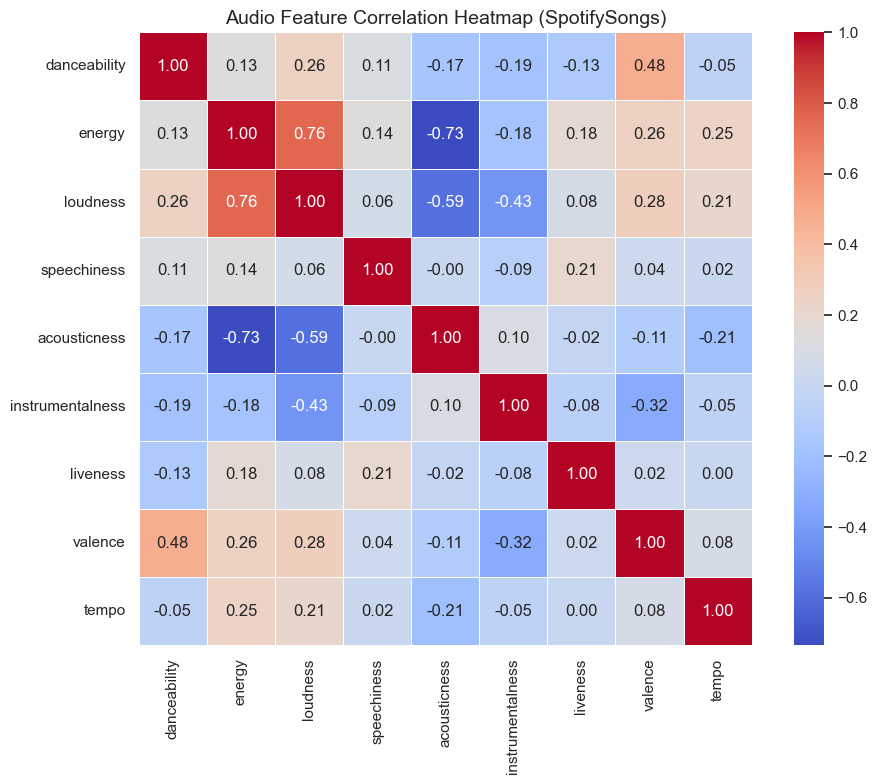

In [7]:
# Cell 6 — Correlation heatmap of audio features (SpotifySongs)
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    spotify[AUDIO_FEATURES].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Audio Feature Correlation Heatmap (SpotifySongs)", fontsize=14)
plt.tight_layout()
plt.show()

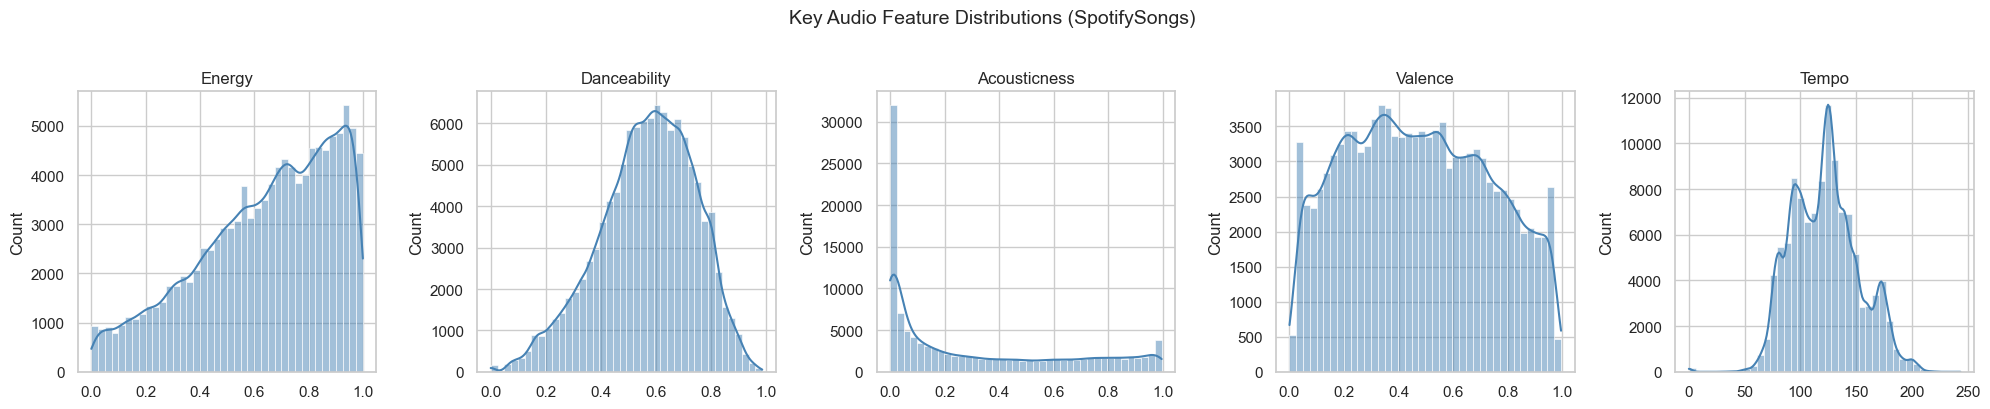

In [8]:
# Cell 7 — Distributions of key audio features (histograms with KDE)
KEY_FEATURES = ['energy', 'danceability', 'acousticness', 'valence', 'tempo']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feature in zip(axes, KEY_FEATURES):
    sns.histplot(spotify[feature], kde=True, ax=ax, color='steelblue', bins=40)
    ax.set_title(feature.capitalize(), fontsize=12)
    ax.set_xlabel("")

plt.suptitle("Key Audio Feature Distributions (SpotifySongs)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()